# MultistageOT

In [36]:
!pip install anndata scanpy

In [4]:
!unzip larry_preprocessed.h5ad.zip

Archive:  larry_preprocessed.h5ad.zip
  inflating: larry_preprocessed.h5ad  
  inflating: __MACOSX/._larry_preprocessed.h5ad  


In [6]:
# Cell 1 — Clone MultistageOT
import os
os.system("git clone https://github.com/dahlinlab/MultistageOT.git")

32768

In [41]:
# Cell 2 — Imports
import sys
import os
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
from scipy.stats import pearsonr

sys.path.insert(0, "MultistageOT")
from packages.models.multistageot import MultistageOT

In [42]:
# Cell 3 — Load preprocessed data
adata = ad.read_h5ad("larry_preprocessed.h5ad")

time_col     = "Time point"
celltype_col = "Cell type annotation"
clone_col    = "clone_idx"
fate_cols    = [c for c in adata.obs.columns if c.startswith("fate_frac_")]

print(adata)
print("\nTime point counts:")
print(adata.obs[time_col].value_counts().sort_index())
print(f"\nFate fraction columns ({len(fate_cols)}):", fate_cols)
print(f"\nDay-2 cells with GT fate fractions: "
      f"{adata.obs.loc[adata.obs[time_col]==2, fate_cols[0]].notna().sum():,}")

AnnData object with n_obs × n_vars = 130887 × 2000
    obs: 'Library', 'Cell barcode', 'Time point', 'Starting population', 'Cell type annotation', 'Well', 'SPRING-x', 'SPRING-y', 'clone_idx', 'fate_train', 'fate_test', 'fate_frac_Baso', 'fate_frac_Ccr7_DC', 'fate_frac_Eos', 'fate_frac_Erythroid', 'fate_frac_Lymphoid', 'fate_frac_Mast', 'fate_frac_Meg', 'fate_frac_Monocyte', 'fate_frac_Neutrophil', 'fate_frac_Undifferentiated', 'fate_frac_pDC'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_clone', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts_norm', 'log1p_norm'
    obsp: 'connectivities', 'distances'

Time point counts:
Time point
2.0    28249
4.0    48498
6.0    54140
Name: count, dtype: int64

Fate fraction columns (11): ['fate_frac_Baso', 'fate_frac_Ccr7_DC', 'fate_frac_Eos', 'fate_frac_Erythroid', 'fate_frac_Lymphoid', 'fate_frac_Mast', 'fate_frac_Meg', 'fate_frac_Monocy

In [43]:
N_SUBSETS          = 12
N_INITIAL_PER      = 80    # up from 10 — more GT coverage
N_TERMINAL_PER     = 581   # full terminal pool
N_INTERMEDIATE_PER = 500   # full intermediate pool

rng = np.random.default_rng(42)

# --- Initial: undiff day-2 cells WITH GT fate fractions only ---
undiff_mask = (adata.obs[time_col] == 2) & (
    adata.obs[celltype_col].astype(str).str.contains("ndiff", case=False, na=False)
)
undiff_cells = adata.obs[undiff_mask]
has_gt = undiff_cells[fate_cols].notna().any(axis=1)
cloned_undiff = undiff_cells[has_gt].index
print(f"Undiff day-2 with GT: {len(cloned_undiff):,}")

initial_sampled = rng.choice(cloned_undiff, size=min(N_SUBSETS * N_INITIAL_PER, len(cloned_undiff)), replace=False)
initial_subsets = [initial_sampled[i*N_INITIAL_PER:(i+1)*N_INITIAL_PER] for i in range(N_SUBSETS)]

# --- Terminal: day-6, proportional to lineage ---
term_mask      = adata.obs[time_col] == 6
adata_term     = adata[term_mask]
term_celltypes = adata_term.obs[celltype_col].astype(str)
term_counts    = term_celltypes[term_celltypes != "nan"].value_counts()
term_fracs     = term_counts / term_counts.sum()
n_term_per_fate = (term_fracs * N_SUBSETS * N_TERMINAL_PER).round().astype(int).clip(lower=1)
diff = (N_SUBSETS * N_TERMINAL_PER) - n_term_per_fate.sum()
n_term_per_fate.iloc[0] += diff

terminal_cells_by_fate = {}
for fate, n in n_term_per_fate.items():
    pool = adata_term.obs.index[term_celltypes == fate]
    terminal_cells_by_fate[fate] = rng.choice(pool, size=min(n, len(pool)), replace=False)

all_terminal = np.concatenate(list(terminal_cells_by_fate.values()))
rng.shuffle(all_terminal)
terminal_subsets = [all_terminal[i*N_TERMINAL_PER:(i+1)*N_TERMINAL_PER] for i in range(N_SUBSETS)]

# --- Intermediate: day-4 cells, 500 per subset ---
day4_idx = adata.obs.index[adata.obs[time_col] == 4]
day4_sampled = rng.choice(day4_idx, size=N_SUBSETS * N_INTERMEDIATE_PER, replace=False)
intermediate_subsets = [day4_sampled[i*N_INTERMEDIATE_PER:(i+1)*N_INTERMEDIATE_PER] for i in range(N_SUBSETS)]

print(f"Initial per subset:      {N_INITIAL_PER}")
print(f"Intermediate per subset: {N_INTERMEDIATE_PER}")
print(f"Terminal per subset:     {N_TERMINAL_PER}")
print(f"Cost matrix per subset:  {N_INITIAL_PER + N_INTERMEDIATE_PER + N_TERMINAL_PER} x "
      f"{N_INITIAL_PER + N_INTERMEDIATE_PER + N_TERMINAL_PER}")

Undiff day-2 with GT: 2,518
Initial per subset:      80
Intermediate per subset: 500
Terminal per subset:     581
Cost matrix per subset:  1161 x 1161


In [ ]:
# Clear cfp before rerunning the loop
all_cfp = []
cfp = None

for i in range(N_SUBSETS):
    print(f"Subset {i+1}/{N_SUBSETS}...")

    subset_idx = list(initial_subsets[i]) + list(intermediate_subsets[i]) + list(terminal_subsets[i])
    adata_sub  = adata[subset_idx]

    X_pca = adata_sub.obsm["X_pca"][:, :50]
    data_df = pd.DataFrame(X_pca, index=adata_sub.obs_names,
                            columns=[f"PC{j+1}" for j in range(50)])
    data_df = (data_df - data_df.mean()) / data_df.std()
    data_df = data_df.dropna(axis=1)

    init_cells = [c for c in list(initial_subsets[i])        if c in data_df.index]
    term_cells = [c for c in list(terminal_subsets[i])       if c in data_df.index]
    # intermediate = everything else in data_df (day-4 cells)

    print(f"  init: {len(init_cells)}, intermediate: {N_INTERMEDIATE_PER}, term: {len(term_cells)}")

    if len(init_cells) == 0 or len(term_cells) == 0:
        print(f"  Skipping subset {i+1}")
        continue

    msot = MultistageOT(
    initial_cells=init_cells,
    terminal_cells=term_cells,
    n_groups=20,        # they use 20, you were using 4
    epsilon=0.055
    )
    msot.fit(data_df, tolerance=1e-4, patience=1000)

    # Then anneal down to a tighter solution:
    msot.proximal_sinkhorn(epsilon_threshold=0.006, patience=1000)

    fate_groups = {}
    for fate in term_celltypes.unique():
        if fate == "nan":
            continue
        cells_in_subset = [
            c for c in term_cells
            if adata.obs.loc[c, celltype_col] == fate
        ]
        if cells_in_subset:
            fate_groups[fate] = cells_in_subset

    cfp_i = msot.cell_fate_probabilities(fate_groups)
    cfp_i = cfp_i.loc[cfp_i.index.isin(set(init_cells))]
    all_cfp.append(cfp_i)
    print(f"  done — cfp shape: {cfp_i.shape}")

cfp = pd.concat(all_cfp)
print(f"\nFinal cfp: {cfp.shape}")

Subset 1/12...
  init: 80, intermediate: 500, term: 581
 Iteration: 6000 [========] Max dual step: 1.434e-05 | Infeasibility: 5.958e-05 | Elapsed time: 0:00:37.472642

Sinkhorn algorithm converged to a solution within the given tolerance (1.0000e-04) of both feasibility and max dual-variable update step.


Retrieving transport plans...
Done.
Storing dual variables...
Done.
Max absolute feasibility errors in the marginal constraints: 
  {'mu_0': np.float64(4.440892098500626e-16), 'mu_sum': np.float64(5.957884582952211e-05), 'max_mu_t': np.float64(1.4121667042843455e-05), 'mu_T': np.float64(7.03382749822623e-08)}


In [46]:
# Estimate typical pairwise cost in this subset
from sklearn.metrics import pairwise_distances
sample_idx = np.random.choice(len(data_df), size=min(200, len(data_df)), replace=False)
sample = data_df.iloc[sample_idx].values
dists  = pairwise_distances(sample, metric="sqeuclidean")
print(f"Pairwise sq-euclidean — median: {np.median(dists):.1f}  mean: {np.mean(dists):.1f}  90th pct: {np.percentile(dists, 90):.1f}")

Pairwise sq-euclidean — median: 78.1  mean: 92.1  90th pct: 151.7


In [31]:
# ── Epsilon sweep: bar plot of Neutrophil fate prediction performance ────────
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# --- Run sweep on subset 0 ---
subset_idx = list(initial_subsets[0]) + list(intermediate_subsets[0]) + list(terminal_subsets[0])
adata_sub  = adata[subset_idx]
X_pca = adata_sub.obsm["X_pca"][:, :50]
data_df = pd.DataFrame(X_pca, index=adata_sub.obs_names,
                        columns=[f"PC{j+1}" for j in range(50)])
data_df = (data_df - data_df.mean()) / data_df.std()
data_df = data_df.dropna(axis=1)

init_cells = [c for c in list(initial_subsets[0]) if c in data_df.index]
term_cells = [c for c in list(terminal_subsets[0]) if c in data_df.index]
fate_groups = {
    fate: [c for c in term_cells if adata.obs.loc[c, celltype_col] == fate]
    for fate in adata.obs[celltype_col].unique() if str(fate) != "nan"
}
fate_groups = {k: v for k, v in fate_groups.items() if v}

epsilons = [0.5, 0.2, 0.1, 0.05, 0.01, 0.005]
results  = []

for eps in epsilons:
    try:
        msot = MultistageOT(initial_cells=init_cells, terminal_cells=term_cells,
                            n_groups=4, epsilon=eps)
        msot.fit(data_df, tolerance=1e-6)
        cfp_test = msot.cell_fate_probabilities(fate_groups)
        cfp_test = cfp_test.loc[cfp_test.index.isin(set(init_cells))]

        # Align with GT
        day2_obs  = adata.obs.loc[cfp_test.index]
        gt_cols   = [c for c in day2_obs.columns if c.startswith("fate_frac_")]
        fate_df_e = day2_obs[gt_cols].copy()
        fate_df_e.columns = [c.replace("fate_frac_", "") for c in gt_cols]
        valid_mask = fate_df_e.notna().any(axis=1)
        fate_sub_e = fate_df_e[valid_mask]
        cfp_sub_e  = cfp_test.loc[valid_mask]

        # Pearson r for each common fate
        common = [f for f in fate_sub_e.columns if f in cfp_sub_e.columns]
        fate_rs = []
        for fate in common:
            v = fate_sub_e[fate].notna() & cfp_sub_e[fate].notna()
            if v.sum() >= 5:
                r, _ = stats.pearsonr(fate_sub_e[fate][v], cfp_sub_e[fate][v])
                fate_rs.append(r)

        mean_r  = np.mean(fate_rs)  if fate_rs else np.nan
        neu_std = cfp_sub_e["Neutrophil"].std() if "Neutrophil" in cfp_sub_e else np.nan
        row_sum = cfp_test.sum(axis=1).mean()
        converged = not cfp_test.isnull().any().any() and abs(row_sum - 1.0) < 0.05

        results.append(dict(epsilon=eps, mean_r=mean_r, neu_std=neu_std,
                            converged=converged, n_fates=len(fate_rs)))
        print(f"eps={eps}  mean_r={mean_r:.3f}  neu_std={neu_std:.5f}  "
              f"row_sum={row_sum:.4f}  converged={converged}")
    except Exception as ex:
        print(f"eps={eps}  FAILED: {ex}")
        results.append(dict(epsilon=eps, mean_r=np.nan, neu_std=np.nan,
                            converged=False, n_fates=0))

res_df = pd.DataFrame(results)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

colors = ["#e07b54" if c else "#b0b0b0" for c in res_df["converged"]]

# Left: mean Pearson r across fates
axes[0].bar(range(len(res_df)), res_df["mean_r"], color=colors, edgecolor="white", width=0.6)
axes[0].axhline(0, color="black", lw=0.8, ls="--")
axes[0].set_xticks(range(len(res_df)))
axes[0].set_xticklabels([str(e) for e in res_df["epsilon"]])
axes[0].set_xlabel("epsilon", fontsize=12)
axes[0].set_ylabel("Mean Pearson r (across fates)", fontsize=12)
axes[0].set_title("Fate prediction accuracy", fontsize=13)
sns.despine(ax=axes[0])

# Right: Neutrophil P std (proxy for how much variance the model produces)
axes[1].bar(range(len(res_df)), res_df["neu_std"], color=colors, edgecolor="white", width=0.6)
axes[1].set_xticks(range(len(res_df)))
axes[1].set_xticklabels([str(e) for e in res_df["epsilon"]])
axes[1].set_xlabel("epsilon", fontsize=12)
axes[1].set_ylabel("Neutrophil P(fate) std", fontsize=12)
axes[1].set_title("Transport variance (higher = more cell-specific)", fontsize=13)
sns.despine(ax=axes[1])

# Legend
from matplotlib.patches import Patch
handles = [Patch(color="#e07b54", label="Converged"), Patch(color="#b0b0b0", label="Did not converge")]
fig.legend(handles=handles, loc="lower center", ncol=2, fontsize=10,
           bbox_to_anchor=(0.5, -0.05), frameon=False)

plt.suptitle("MultistageOT epsilon sweep (subset 0)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("epsilon_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

 Iteration: 25 [========] Max dual step: 1.209e-07 | Infeasibility: 7.626e-07 | Elapsed time: 0:00:00.120767

Sinkhorn algorithm converged to a solution within the given tolerance (1.0000e-06) of both feasibility and max dual-variable update step.


Retrieving transport plans...
Done.
Storing dual variables...
Done.
Max absolute feasibility errors in the marginal constraints: 
  {'mu_0': np.float64(0.0), 'mu_sum': np.float64(1.2752561284745667e-07), 'max_mu_t': np.float64(7.625596651905653e-07), 'mu_T': np.float64(5.805985359152999e-09)}
eps=0.5  mean_r=0.207  neu_std=0.00044  row_sum=1.0000  converged=True
 Iteration: 75 [========] Max dual step: 2.722e-07 | Infeasibility: 6.711e-07 | Elapsed time: 0:00:00.356979

Sinkhorn algorithm converged to a solution within the given tolerance (1.0000e-06) of both feasibility and max dual-variable update step.


Retrieving transport plans...
Done.
Storing dual variables...
Done.
Max absolute feasibility errors in the marginal constraints: 
  {'m

KeyboardInterrupt: 

Fitted exponent: 2.84  (pure theory = 2.0)


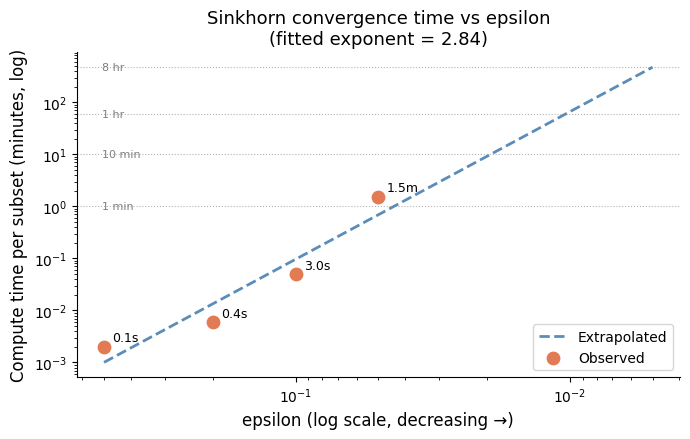


   epsilon    predicted time
     0.500              0.1s
     0.200              0.8s
     0.100              5.8s
     0.050             41.4s
     0.010              1.1h
     0.005              7.9h


In [32]:
# ── Epsilon vs compute time (observed + extrapolated) ────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Observed data points (from your run)
eps_obs  = np.array([0.5,   0.2,   0.1,    0.05])
time_obs = np.array([0.121, 0.357, 2.978,  91.56])   # seconds

# Sinkhorn iterations scale as O(1/eps^2) empirically
# Fit log-log linear model: log(t) = a * log(1/eps) + b
log_inv_eps = np.log(1.0 / eps_obs)
log_time    = np.log(time_obs)
a, b        = np.polyfit(log_inv_eps, log_time, 1)
print(f"Fitted exponent: {a:.2f}  (pure theory = 2.0)")

eps_pred  = np.array([0.5, 0.2, 0.1, 0.05, 0.01, 0.005])
time_pred = np.exp(b) * (1.0 / eps_pred) ** a

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(eps_pred, time_pred / 60, color="#5b8db8", lw=2, ls="--", label="Extrapolated")
ax.scatter(eps_obs, time_obs / 60, color="#e07b54", s=80, zorder=5, label="Observed")

# Annotate observed points
for eps, t in zip(eps_obs, time_obs):
    label = f"{t:.1f}s" if t < 60 else f"{t/60:.1f}m"
    ax.annotate(label, (eps, t/60), textcoords="offset points",
                xytext=(6, 4), fontsize=9)

# Reference lines
for mins, label in [(1, "1 min"), (10, "10 min"), (60, "1 hr"), (480, "8 hr")]:
    if mins <= time_pred.max() / 60 * 1.2:
        ax.axhline(mins, color="gray", lw=0.8, ls=":", alpha=0.6)
        ax.text(eps_pred.max() * 1.02, mins, label, va="center", fontsize=8, color="gray")

ax.set_xscale("log")
ax.set_yscale("log")
ax.invert_xaxis()
ax.set_xlabel("epsilon (log scale, decreasing →)", fontsize=12)
ax.set_ylabel("Compute time per subset (minutes, log)", fontsize=12)
ax.set_title(f"Sinkhorn convergence time vs epsilon\n(fitted exponent = {a:.2f})", fontsize=13)
ax.legend(fontsize=10)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("epsilon_compute_time.png", dpi=150, bbox_inches="tight")
plt.show()

# Print prediction table
print(f"\n{'epsilon':>10}  {'predicted time':>16}")
for eps, t in zip(eps_pred, time_pred):
    if t < 60:      tstr = f"{t:.1f}s"
    elif t < 3600:  tstr = f"{t/60:.1f}m"
    else:           tstr = f"{t/3600:.1f}h"
    print(f"{eps:>10.3f}  {tstr:>16}")

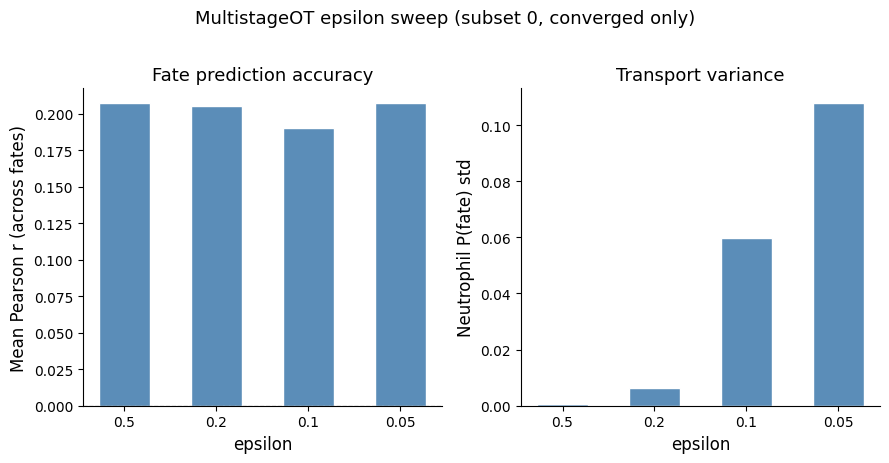

In [33]:
# ── Accuracy bar plot for converged epsilon values only ──────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Results from your completed runs
completed = [
    dict(epsilon=0.5,  mean_r=0.207, neu_std=0.00044),
    dict(epsilon=0.2,  mean_r=0.205, neu_std=0.00615),
    dict(epsilon=0.1,  mean_r=0.190, neu_std=0.05977),
    dict(epsilon=0.05, mean_r=0.207, neu_std=0.10768),
]
eps_vals  = [d["epsilon"]  for d in completed]
mean_rs   = [d["mean_r"]   for d in completed]
neu_stds  = [d["neu_std"]  for d in completed]

x = np.arange(len(eps_vals))
colors = ["#5b8db8"] * len(eps_vals)

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))

# Left: mean Pearson r
axes[0].bar(x, mean_rs, color=colors, edgecolor="white", width=0.55)
axes[0].axhline(0, color="black", lw=0.8, ls="--")
axes[0].set_xticks(x)
axes[0].set_xticklabels([str(e) for e in eps_vals])
axes[0].set_xlabel("epsilon", fontsize=12)
axes[0].set_ylabel("Mean Pearson r (across fates)", fontsize=12)
axes[0].set_title("Fate prediction accuracy", fontsize=13)
sns.despine(ax=axes[0])

# Right: Neutrophil std
axes[1].bar(x, neu_stds, color=colors, edgecolor="white", width=0.55)
axes[1].set_xticks(x)
axes[1].set_xticklabels([str(e) for e in eps_vals])
axes[1].set_xlabel("epsilon", fontsize=12)
axes[1].set_ylabel("Neutrophil P(fate) std", fontsize=12)
axes[1].set_title("Transport variance", fontsize=13)
sns.despine(ax=axes[1])

plt.suptitle("MultistageOT epsilon sweep (subset 0, converged only)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("epsilon_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

Cells with GT fate fractions: 2,400
Common fates: ['Baso', 'Ccr7_DC', 'Eos', 'Erythroid', 'Lymphoid', 'Mast', 'Meg', 'Monocyte', 'Neutrophil', 'Undifferentiated', 'pDC']

Pearson r (observed fate fraction × MultistageOT fate probability):
                  Undifferentiated  Monocyte  Neutrophil   Baso   Mast    Meg  Lymphoid    Eos  Ccr7_DC  Erythroid    pDC
Baso                        -0.007    -0.034       0.019  0.024  0.006 -0.012     0.045  0.072   -0.038     -0.039 -0.034
Ccr7_DC                      0.011    -0.011      -0.003  0.011 -0.026 -0.005    -0.014 -0.026    0.073      0.008 -0.010
Eos                         -0.021     0.030       0.002 -0.017  0.028  0.010    -0.023  0.017   -0.010     -0.002 -0.024
Erythroid                    0.007     0.002      -0.000 -0.021 -0.007  0.003     0.008  0.008    0.011      0.033 -0.014
Lymphoid                     0.001     0.008      -0.004 -0.011  0.007  0.001     0.080  0.010    0.022     -0.017 -0.038
Mast                         

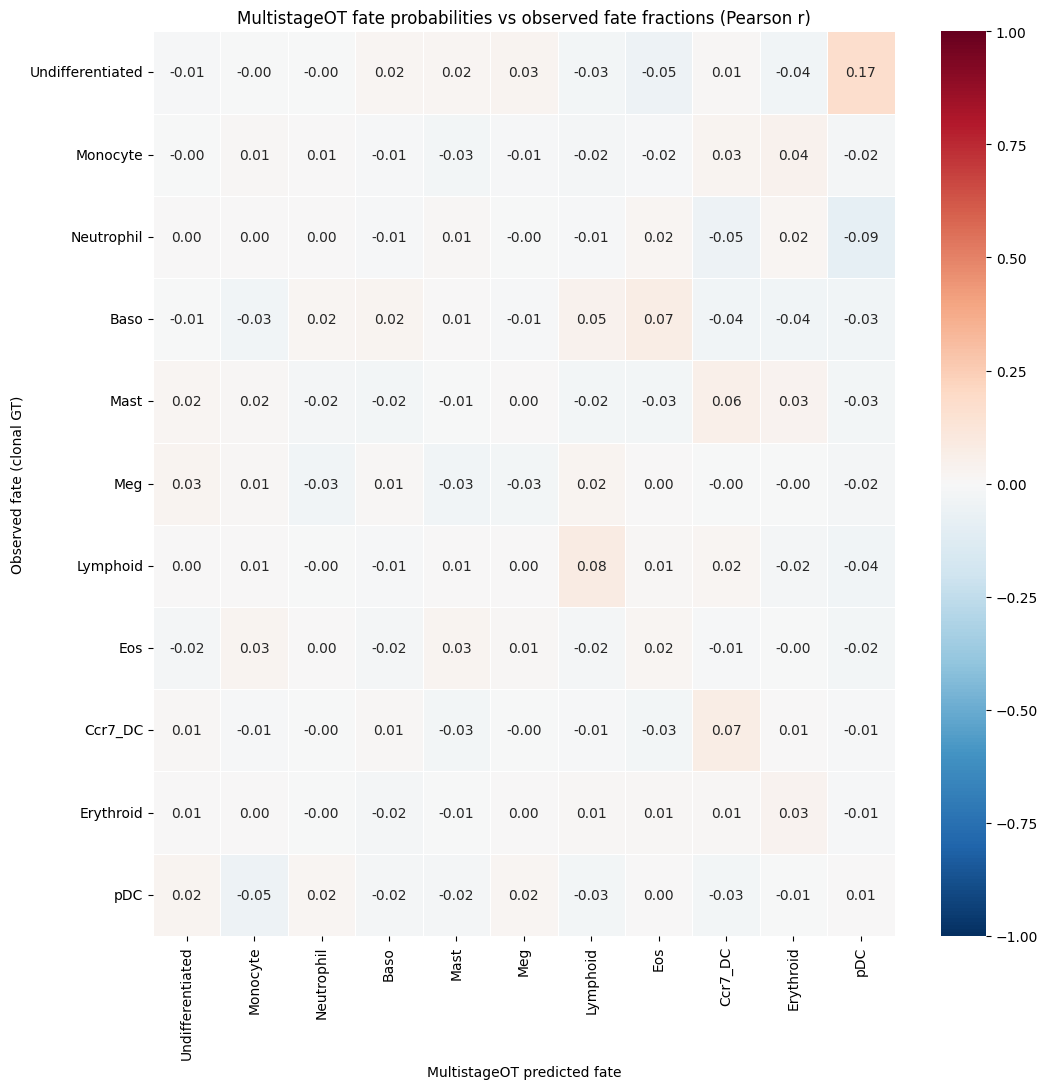

In [26]:
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# --- Build fate probability DataFrame from cfp ---
# cfp index = initial cell names, columns = fate names
# Align with ground-truth fate fractions

day2_obs = adata.obs.loc[cfp.index]

# Ground-truth fate fraction columns -> strip "fate_frac_" prefix for clean labels
gt_cols = [c for c in day2_obs.columns if c.startswith("fate_frac_")]
fate_df = day2_obs[gt_cols].copy()
fate_df.columns = [c.replace("fate_frac_", "") for c in gt_cols]

# Only keep cells with at least one non-NaN GT fate fraction
valid_mask = fate_df.notna().any(axis=1)
fate_sub = fate_df[valid_mask]
cfp_sub  = cfp.loc[valid_mask]

# Align columns: only fates present in both
common_fates = [f for f in fate_sub.columns if f in cfp_sub.columns]
print(f"Cells with GT fate fractions: {valid_mask.sum():,}")
print(f"Common fates: {common_fates}")

# --- Pearson r matrix: GT fate fraction x predicted fate probability ---
corr_mat = np.zeros((len(fate_sub.columns), len(cfp_sub.columns)))
for i, fc in enumerate(fate_sub.columns):
    for j, bc in enumerate(cfp_sub.columns):
        valid = fate_sub[fc].notna() & cfp_sub[bc].notna()
        if valid.sum() >= 5:
            corr_mat[i, j], _ = stats.pearsonr(fate_sub[fc][valid], cfp_sub[bc][valid])
        else:
            corr_mat[i, j] = np.nan

corr_df = pd.DataFrame(corr_mat, index=fate_sub.columns, columns=cfp_sub.columns)
print("\nPearson r (observed fate fraction × MultistageOT fate probability):")
print(corr_df.round(3).to_string())

# --- Neu-Mon bias ---
if "Neutrophil" in cfp_sub.columns and "Monocyte" in cfp_sub.columns:
    gt_bias   = fate_sub.get("Neutrophil", np.nan) - fate_sub.get("Monocyte", np.nan)
    pred_bias = cfp_sub["Neutrophil"] - cfp_sub["Monocyte"]
    valid = gt_bias.notna() & pred_bias.notna()
    r_bias, p_bias = stats.pearsonr(gt_bias[valid], pred_bias[valid])
    print(f"\nNeu-Mon bias Pearson r: {r_bias:.3f} (p={p_bias:.3e}, n={valid.sum()})")

# --- Heatmap ---
# Reorder: fates on diagonal (where GT col == predicted col) first
identified   = [c for c in corr_df.columns if c in corr_df.index]
unidentified = [r for r in corr_df.index   if r not in corr_df.columns]
corr_df_plot = corr_df.loc[identified + unidentified]

fig_w = max(6, len(cfp_sub.columns))
fig_h = max(4, len(corr_df_plot))
fig, ax = plt.subplots(figsize=(fig_w, fig_h))
sns.heatmap(
    corr_df_plot, annot=True, fmt=".2f", cmap="RdBu_r",
    vmin=-1, vmax=1, ax=ax, linewidths=0.5
)
ax.set_title("MultistageOT fate probabilities vs observed fate fractions (Pearson r)")
ax.set_xlabel("MultistageOT predicted fate")
ax.set_ylabel("Observed fate (clonal GT)")
plt.tight_layout()
plt.savefig("multistageot_corr_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

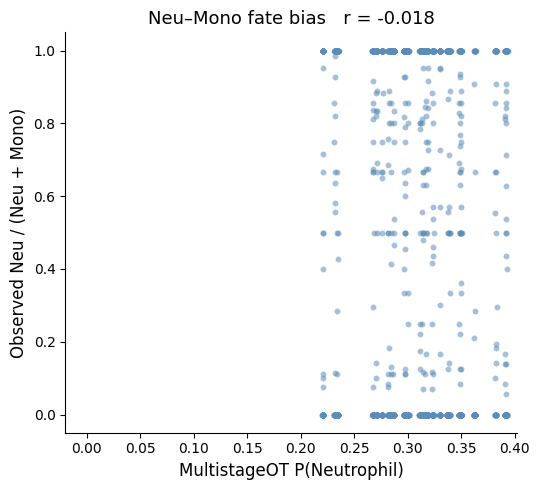

Pearson r = -0.018  (p = 5.07e-01,  n = 1389)


In [27]:
# ── Neu-Mono fate bias scatter ──────────────────────────────────────────────
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

if "Neutrophil" in cfp_sub.columns and "Monocyte" in cfp_sub.columns:
    pred_neu  = cfp_sub["Neutrophil"]
    gt_neu    = fate_sub.get("Neutrophil", pd.Series(np.nan, index=fate_sub.index))
    gt_mono   = fate_sub.get("Monocyte",   pd.Series(np.nan, index=fate_sub.index))

    # Observed Neu / (Neu + Mono)  — same quantity on y-axis as reference plot
    denom     = gt_neu + gt_mono
    gt_ratio  = gt_neu / denom.replace(0, np.nan)

    valid = pred_neu.notna() & gt_ratio.notna()
    r, p  = stats.pearsonr(pred_neu[valid], gt_ratio[valid])

    fig, ax = plt.subplots(figsize=(5.5, 5))
    ax.scatter(pred_neu[valid], gt_ratio[valid],
               s=18, alpha=0.55, color="#5b8db8", linewidths=0)

    ax.set_xlabel("MultistageOT P(Neutrophil)", fontsize=12)
    ax.set_ylabel("Observed Neu / (Neu + Mono)", fontsize=12)
    ax.set_title(f"Neu–Mono fate bias   r = {r:.3f}", fontsize=13)
    ax.set_xlim(-0.02, ax.get_xlim()[1])
    ax.set_ylim(-0.05, 1.05)
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.savefig("multistageot_neu_mono_bias.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Pearson r = {r:.3f}  (p = {p:.2e},  n = {valid.sum()})")
else:
    print("Neutrophil or Monocyte not found in cfp columns:", cfp_sub.columns.tolist())

In [28]:
print(f"  cfp_i Neutrophil range: {cfp_i['Neutrophil'].min():.4f} – {cfp_i['Neutrophil'].max():.4f}  std={cfp_i['Neutrophil'].std():.5f}")
print(f"  cfp_i sample:\n{cfp_i.head(3).round(4)}")

  cfp_i Neutrophil range: 0.3482 – 0.3499  std=0.00031
  cfp_i sample:
       Undifferentiated  Monocyte  Neutrophil    Baso   Mast  Erythroid  \
17366            0.3968    0.1562      0.3487  0.0592  0.014     0.0105   
16119            0.3966    0.1560      0.3494  0.0591  0.014     0.0104   
18188            0.3966    0.1560      0.3495  0.0591  0.014     0.0104   

          Meg     Eos  
17366  0.0135  0.0011  
16119  0.0135  0.0011  
18188  0.0134  0.0011  


# Subset sizes

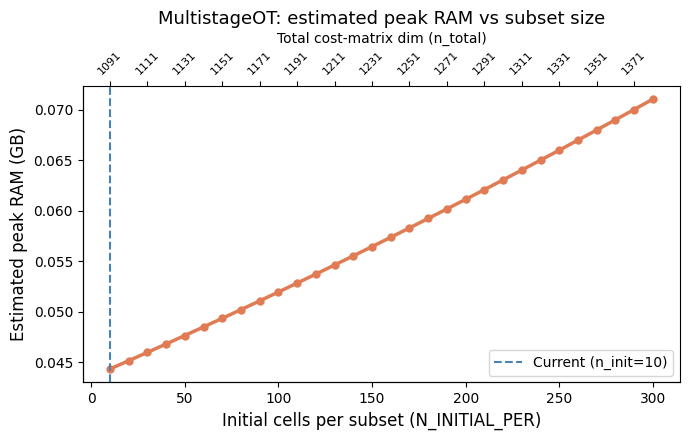


Subset size table:
  n_init   n_total    est. peak RAM (GB)
      10      1091                0.0443 ← current
      20      1101                0.0452
      30      1111                0.0460
      40      1121                0.0468
      50      1131                0.0477
      60      1141                0.0485
      70      1151                0.0494
      80      1161                0.0502
      90      1171                0.0511
     100      1181                0.0520
     110      1191                0.0528
     120      1201                0.0537
     130      1211                0.0546
     140      1221                0.0555
     150      1231                0.0565
     160      1241                0.0574
     170      1251                0.0583
     180      1261                0.0592
     190      1271                0.0602
     200      1281                0.0611
     210      1291                0.0621
     220      1301                0.0631
     230      1311         

In [14]:
# ── Subset-size sweep: estimated peak RAM vs subset size ────────────────────
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Fixed params from your current run
N_INTERMEDIATE_FIXED = 500
N_TERMINAL_FIXED     = 581
BYTES_PER_FLOAT64    = 8
GB                   = 1024**3

# Sweep initial cells per subset
initial_sizes = np.arange(10, 301, 10)

peak_ram_gb = []
total_sizes = []

for n_init in initial_sizes:
    n_total = n_init + N_INTERMEDIATE_FIXED + N_TERMINAL_FIXED
    total_sizes.append(n_total)

    # Cost matrix: n_total x n_total (float64)
    cost_matrix_gb = (n_total ** 2 * BYTES_PER_FLOAT64) / GB

    # Transport plan (same shape) + working buffers (~3–4 copies during Sinkhorn)
    estimated_peak_gb = cost_matrix_gb * 5   # cost + plan + 3 working buffers

    peak_ram_gb.append(estimated_peak_gb)

fig, ax1 = plt.subplots(figsize=(7, 4.5))

ax1.plot(initial_sizes, peak_ram_gb, color="#e07b54", lw=2.5, marker="o", ms=5)
ax1.axvline(x=10, color="steelblue", ls="--", lw=1.5, label=f"Current (n_init=10)")
ax1.set_xlabel("Initial cells per subset (N_INITIAL_PER)", fontsize=12)
ax1.set_ylabel("Estimated peak RAM (GB)", fontsize=12)
ax1.set_title("MultistageOT: estimated peak RAM vs subset size", fontsize=13)
ax1.legend(fontsize=10)

# Secondary x-axis: total cost-matrix dimension
ax2 = ax1.twiny()
ax2.set_xlim(ax1.get_xlim())
tick_locs = initial_sizes[::2]
ax2.set_xticks(tick_locs)
ax2.set_xticklabels([str(n_init + N_INTERMEDIATE_FIXED + N_TERMINAL_FIXED) for n_init in tick_locs],
                    rotation=45, fontsize=8)
ax2.set_xlabel("Total cost-matrix dim (n_total)", fontsize=10)

sns.despine(ax=ax1)
plt.tight_layout()
plt.savefig("multistageot_ram_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSubset size table:")
print(f"{'n_init':>8}  {'n_total':>8}  {'est. peak RAM (GB)':>20}")
for n_init, n_total, ram in zip(initial_sizes, total_sizes, peak_ram_gb):
    flag = " ← current" if n_init == 10 else ""
    print(f"{n_init:>8}  {n_total:>8}  {ram:>20.4f}{flag}")